""

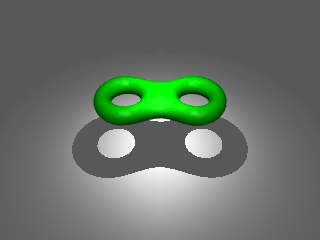

In [12]:
import mujoco
import mediapy

    # <mesh name="table_collision_0" file="../models/table/table_collision_0.obj"/>
    # <mesh name="table_collision_1" file="../models/table/table_collision_1.obj"/>
    # <mesh name="table_collision_2" file="../models/table/table_collision_2.obj"/>
    # <mesh name="table_collision_3" file="../models/table/table_collision_3.obj"/>
    # <mesh name="table_collision_4" file="../models/table/table_collision_4.obj"/>

xml = """
<mujoco>
  <default>
    <default class="collision">
        <geom group="0" type="mesh"/>
    </default>
  </default>

  <asset>
    <mesh name="eight" file="../models/eight.obj"/>
    <mesh name="table_collision_0" file="../models/table/table_collision_0.obj"/>
  </asset>

  <worldbody>
    <light pos="0 0 3" dir="0 0 -1" diffuse="0.8 0.8 0.8"/>

    <!-- 平面 -->
    <geom name="ground" type="plane" size="10 10 0.1" pos="0 0 0" rgba="0.9 0.9 0.9 1"/>
    
    <!-- 盒子 -->
    <!-- <geom name="box1" type="box" size="0.5 0.5 0.5" pos="2 0 0.5" euler="45 -45 0" rgba="1 0 0 1"/> -->
    
    <!-- 球体 -->
    <!-- <geom name="sphere1" type="sphere" size="0.5" pos="0 2 0.5" rgba="0 1 0 1"/> -->
    
    <!-- 圆柱体 -->
    <!-- <geom name="cylinder1" type="cylinder" size="0.4 0.6" pos="0 -2 0.4" euler="0 90 0" rgba="0 0 1 1"/> -->
  
    <geom mesh="eight" pos="0 0 1" euler="90 90 0" rgba="0 1 0 1" class="collision"/>

    <!-- <geom mesh="table_collision_4" pos="0.5 0 0.5" rgba="0.6763935617492491 0.3553562717391734 0.36429453230811604 1" class="collision"/> -->

    <!-- <geom mesh="table_collision_2" pos="0 0.5 0.5" rgba="0.6763935617492491 0.3553562717391734 0.36429453230811604 1" class="collision"/> -->

  </worldbody>
</mujoco>
"""

mj_model = mujoco.MjModel.from_xml_string(xml)
mj_data = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model, height=240, width=320, max_geom=100)
mujoco.mj_forward(mj_model, mj_data)
renderer.update_scene(mj_data)
mediapy.show_image(renderer.render())

In [13]:
# 创建场景渲染对象
mj_scene = mujoco.MjvScene(mj_model, maxgeom=100)

# 更新场景
mujoco.mjv_updateScene(
    mj_model, mj_data, mujoco.MjvOption(), 
    None, mujoco.MjvCamera(), 
    mujoco.mjtCatBit.mjCAT_ALL.value, mj_scene
)

In [14]:
for i in range(mj_scene.ngeom):
    # if i != 4:
    #     continue
    geom = mj_scene.geoms[i]
    print(">>>>>>>>>>>>\n", f"geom {i}: ")
    print(f"type={geom.type}, objtype={geom.objtype}, dataid={geom.dataid}")
    print(f"size={geom.size}, pos={geom.pos}, mat=\n{geom.mat}")

>>>>>>>>>>>>
 geom 0: 
type=0, objtype=5, dataid=0
size=[10.  10.   0.1], pos=[0. 0. 0.], mat=
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
>>>>>>>>>>>>
 geom 1: 
type=7, objtype=5, dataid=0
size=[0.20706573 0.48188296 1.001532  ], pos=[-1.5320221e-03 -1.4979560e-04  1.0008168e+00], mat=
[[-1.0508245e-05  7.3400186e-04  9.9999970e-01]
 [ 1.8720413e-05 -9.9999970e-01  7.3400204e-04]
 [ 1.0000000e+00  1.8728122e-05  1.0494502e-05]]


In [15]:
face_addr = mj_model.mesh_faceadr[0]
face_num = mj_model.mesh_facenum[0]
print(face_addr, face_num)
vertex = mj_model.mesh_vert

for i in range(face_addr, face_addr+face_num):
    vertex_ids = vertex[mj_model.mesh_face[i]]
    print(vertex_ids)
    break

0 2022
[[ 0.11858879 -0.41137037 -0.66169393]
 [ 0.08664469 -0.41415522 -0.7233583 ]
 [ 0.12672776 -0.37409386 -0.72522724]]


In [16]:
print(mj_model.bvh_aabb.shape)
print(mj_scene.geoms)

(4317, 6)
(<MjvGeom
  camdist: 0.0
  category: 1
  dataid: 0
  emission: 0.0
  label: ''
  mat: array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)
  matid: -1
  modelrbound: 0.0
  objid: 0
  objtype: 5
  pos: array([0., 0., 0.], dtype=float32)
  reflectance: 0.0
  rgba: array([0.9, 0.9, 0.9, 1. ], dtype=float32)
  segid: 0
  shininess: 0.5
  size: array([10. , 10. ,  0.1], dtype=float32)
  specular: 0.5
  texcoord: 0
  transparent: 0
  type: 0
>, <MjvGeom
  camdist: 0.0
  category: 1
  dataid: 0
  emission: 0.0
  label: ''
  mat: array([[-1.0508245e-05,  7.3400186e-04,  9.9999970e-01],
       [ 1.8720413e-05, -9.9999970e-01,  7.3400204e-04],
       [ 1.0000000e+00,  1.8728122e-05,  1.0494502e-05]], dtype=float32)
  matid: -1
  modelrbound: 1.1305545568466187
  objid: 1
  objtype: 5
  pos: array([-1.5320221e-03, -1.4979560e-04,  1.0008168e+00], dtype=float32)
  reflectance: 0.0
  rgba: array([0., 1., 0., 1.], dtype=float32)
  segid: 1
  shininess: 0.5
  size:

In [17]:
print(mj_model.mesh_bvhadr)
print(mj_model.mesh_bvhnum)

[   3 4046]
[4043  271]


In [32]:
import numpy as np
np.set_printoptions(suppress=True, precision=2, linewidth=500)

print(np.min(mj_model.bvh_aabb[3:4046, :3], axis=0))
print(np.max(mj_model.bvh_aabb[3:4046, 3:], axis=0))


[-0.2  -0.48 -1.  ]
[0.21 0.48 1.  ]


In [31]:
mj_model.bvh_aabb[3]

array([-0.  , -0.  ,  0.  ,  0.21,  0.48,  1.  ])